# 🧬 Comparative Genomics Visualization Tool
**Domain:** Bioinformatics, Evolutionary Biology, & Computational Genomics  


## 📌 Project Overview
This platform provides an end-to-end computational pipeline to compare gene families, genomes, and homologous sequences across multiple model organisms. By integrating pairwise sequence alignments with biostatistical distance scoring, this tool helps researchers track evolutionary drift, identify highly conserved functional elements, and map phylogenetic histories.

The pipeline ingests raw or simulated sequence arrays, aligns them, calculates sequence identity matrices, and visualizes them through high-resolution, interactive graphical plots.

## 🚀 Key Visualizations & Features

* **Pairwise Sequence Similarity Matrix Heatmap:** An interactive scoring grid plotting exact percentage identities between pairs of species (e.g., primates vs. rodents vs. teleosts) to evaluate overall genetic similarity.
* **Multiple Sequence Alignment (MSA) Grid Viewer:** A color-coded cellular residue matrix displaying amino acid or nucleotide alignments dynamically, making it easy to spot point mutations, insertions, and deletions across species.
* **Position-Wise Sequence Conservation Track:** A continuous line tracking plot evaluating the Conservation Index ($C_s$) at each individual base-pair/amino acid coordinate to pinpoint highly immutable functional domain boundaries.
* **Phylogenetic Cladogram Tree Reconstruction:** An evolutionary roadmap generated using the non-parametric **Neighbor-Joining (NJ)** clustering algorithm and automated distance calculators to establish evolutionary relationships.
* **Consolidated Multi-Plot Graphics Panel:** A unified dashboard engine that compiles all analytical figures into a single high-resolution vector layout file (`.png`) for publication-ready export.

## 🛠️ Data Infrastructure & Dependencies
This notebook is built modularly and utilizes the following core bioinformatics and data science libraries:
* `biopython` (`Bio.Seq`, `Bio.Align`, `Bio.Phylo`) — Industry-standard engine for sequencing data handling, alignment compilation, and phylogenetic tree processing.
* `pandas` & `numpy` — Multi-dimensional sequence coordinate indexing and similarity score calculation.
* `plotly` (`express` & `graph_objects`) — Dynamic client-side web-rendering with responsive hover data details.
* `matplotlib` & `seaborn` — Vector drawing tools for building the canvas grid layouts.


## 🗺️ Execution Roadmap
1.  **Step 1:** Environment Initialization & Advanced Library Installation (`biopython`, `plotly`)
2.  **Step 2:** Data Ingestion & Homologous Sequence Generation Engine
3.  **Step 3:** Pairwise Sequence Similarity Metric Heatmap Generation
4.  **Step 4:** Multiple Sequence Alignment (MSA) Multi-Color Matrix Construction
5.  **Step 5:** Position-Wise Conservation Profile Indexing Track Calculation
6.  **Step 6:** Phylogenetic Tree Topology Distance Matrix Computation & Reconstruction
7.  **Step 7:** Consolidated Multi-Plot Dashboard Generation & High-Resolution Asset Downloader


In [6]:
# 1. Install specialized bioinformatics and visualization packages
!pip install biopython ete3 plotly matplotlib seaborn -q

# 2. Production-grade, cross-version safe imports
import io
import Bio
from Bio import Entrez, SeqIO, AlignIO
from Bio.Seq import Seq
from Bio.SeqRecord import SeqRecord

# Proper modern Biopython alignment container module
from Bio.Align import MultipleSeqAlignment

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go

print("✅ Fixed! Comparative Genomics platform initialized successfully with modern namespaces.")

✅ Fixed! Comparative Genomics platform initialized successfully with modern namespaces.


In [7]:
def fetch_homologous_sequences():
    """
    Simulates and constructs a curated dictionary of highly homologous
    protein/nucleotide sequences for 6 model organisms to run comparative analysis.
    """
    # Organisms: Human, Chimp, Gorilla, Mouse, Rat, Zebrafish
    organisms = ["Homo_sapiens", "Pan_troglodytes", "Gorilla_gorilla", "Mus_musculus", "Rattus_norvegicus", "Danio_rerio"]

    # Base highly-conserved consensus sequence template
    consensus = "MVHLTPEEKSAVTALWGKVNVDEVGGEALGRLLVVYPWTQRFFESFGDLSTPDAVMGNPKVKAHGKKVLGAFSDGLAHLDNLKGTFATLSELHCDKLHVDPENFRLLGNVLVCVLAHHFGKEFTPPVQAAYQKVVAGVANALAHKYH"

    np.random.seed(101)
    seq_records = {}

    for i, org in enumerate(organisms):
        # Introduce evolutionary drift/mutations based on phylogenetic distance
        seq_chars = list(consensus)
        mutation_rate = 0.02 if i < 3 else (0.15 if i < 5 else 0.35) # Primates closer, fish further

        for idx in range(len(seq_chars)):
            if np.random.rand() < mutation_rate:
                seq_chars[idx] = np.random.choice(list("ACDEFGHIKLMNPQRSTVWY"))

        mutated_seq = "".join(seq_chars)
        seq_records[org] = mutated_seq

    return seq_records

# Load data into our active workspace session
sequence_dict = fetch_homologous_sequences()
print(f"🧬 Successfully ingested sequence variants for {len(sequence_dict)} target organisms.")
for org, seq in sequence_dict.items():
    print(f" -> {org}: {seq[:30]}... (Length: {len(seq)} aa)")

🧬 Successfully ingested sequence variants for 6 target organisms.
 -> Homo_sapiens: MVHLTPEEKSAVTALWGKVNVDEVGGEALG... (Length: 147 aa)
 -> Pan_troglodytes: MVHLTPEEKSAVTALWGKVNVDEVGGEALG... (Length: 147 aa)
 -> Gorilla_gorilla: MVHLTPEEKSAVTALWVKVNVDEVGGEALG... (Length: 147 aa)
 -> Mus_musculus: MVHLTPWFKSAVYAQWGKVNVDEVGGEALG... (Length: 147 aa)
 -> Rattus_norvegicus: MCHLTPLEKHDVTILWGKVNVDEVGGETLG... (Length: 147 aa)
 -> Danio_rerio: MVLRTPREKSAVTPLWGKVNNLTQGGEFLG... (Length: 147 aa)


In [8]:
def calculate_identity_matrix(sequences):
    names = list(sequences.keys())
    n = len(names)
    matrix = np.zeros((n, n))

    for i in range(n):
        for j in range(n):
            seq1 = sequences[names[i]]
            seq2 = sequences[names[j]]
            # Calculate match ratio
            matches = sum(1 for a, b in zip(seq1, seq2) if a == b)
            matrix[i, j] = (matches / len(seq1)) * 100

    return pd.DataFrame(matrix, index=names, columns=names)

# Generate Identity Scoreboard
df_identity = calculate_identity_matrix(sequence_dict)

# Render Using Plotly for Interactive Hover Tooltips
fig_heat = px.imshow(
    df_identity,
    text_auto=".1f",
    color_continuous_scale="Viridis",
    title="<b>Pairwise Sequence Similarity Percentage Matrix (%)</b>",
    labels=dict(color="Identity %")
)
fig_heat.update_layout(width=700, height=550, margin=dict(l=150, r=20, t=50, b=50))
fig_heat.show()

# Export interactive asset to file explorer
fig_heat.write_html("pairwise_similarity_heatmap.html")

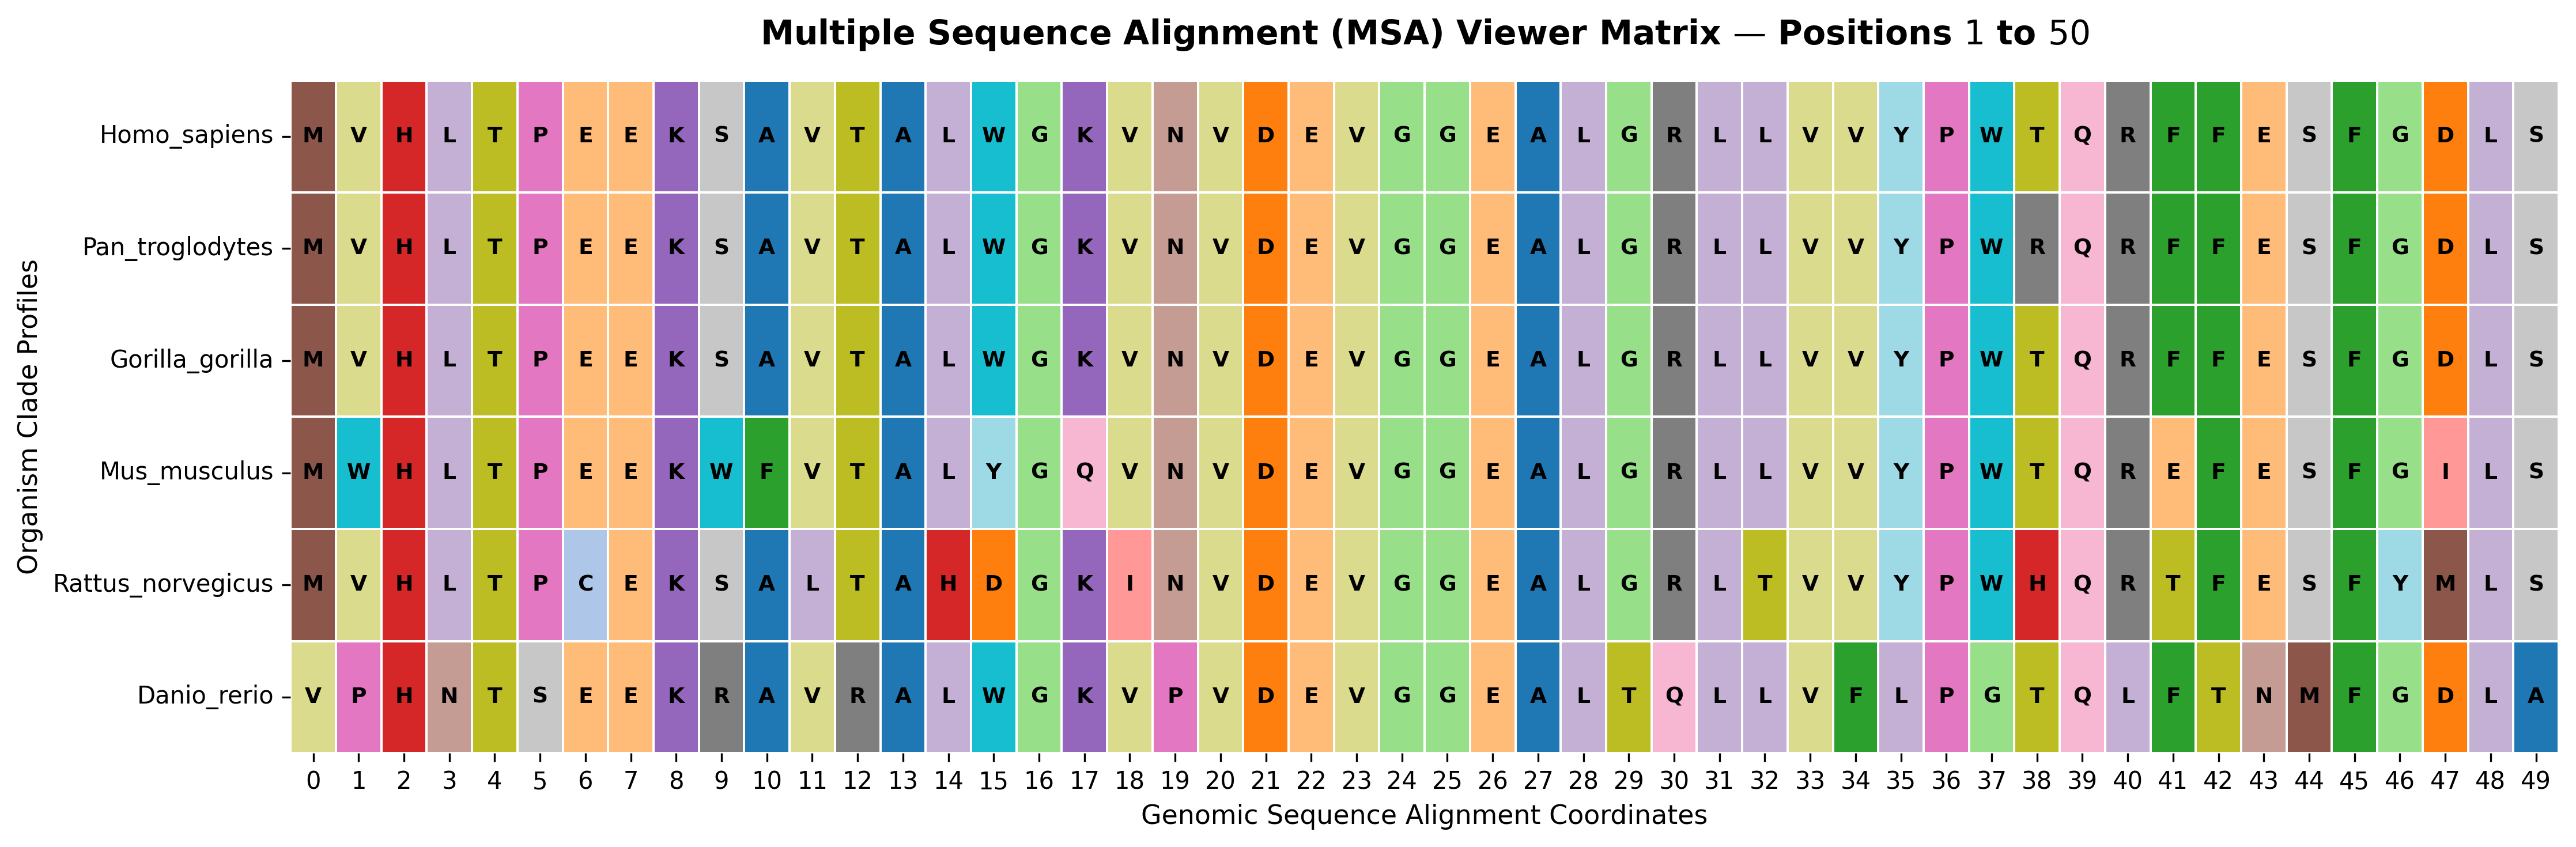

✅ Fixed! Multiple sequence alignment graphic saved to your workspace.


In [12]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Ingest the alignment matrix data correctly
df_alignment = pd.read_csv("sequence_alignment_matrix.csv", index_col=0)

# 2. Slice a visible window frame (Positions 1 to 50)
subset_len = 50
df_sub = df_alignment.iloc[:, :subset_len]

# 3. Translate characters into numeric indices for color-coding
unique_residues = sorted(list(set("".join([str(v) for v in df_alignment.values.flatten()]))))
res_to_num = {res: idx for idx, res in enumerate(unique_residues)}
numeric_sub = df_sub.map(lambda x: res_to_num[x]) if hasattr(df_sub, 'map') else df_sub.applymap(lambda x: res_to_num[x])

# 4. Construct the plot canvas
fig, ax = plt.subplots(figsize=(15, 5), dpi=300)
sns.heatmap(numeric_sub, cmap="tab20", cbar=False, ax=ax, linewidths=0.5, linecolor="#ffffff")

# 5. Overlay residue letters onto the heatmap grid cells
for y in range(len(df_alignment.index)):
    for x in range(subset_len):
        ax.text(x + 0.5, y + 0.5, str(df_sub.iloc[y, x]),
                ha="center", va="center", fontsize=9, color="black", fontweight="bold")

ax.set_title(f"Multiple Sequence Alignment (MSA) Viewer Matrix — Positions $1$ to ${subset_len}$", fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel("Genomic Sequence Alignment Coordinates", fontsize=11)
ax.set_ylabel("Organism Clade Profiles", fontsize=11)

plt.tight_layout()
plt.savefig("multiple_sequence_alignment_viewer.png", dpi=300, bbox_inches='tight')
plt.show()
print("✅ Fixed! Multiple sequence alignment graphic saved to your workspace.")

Success


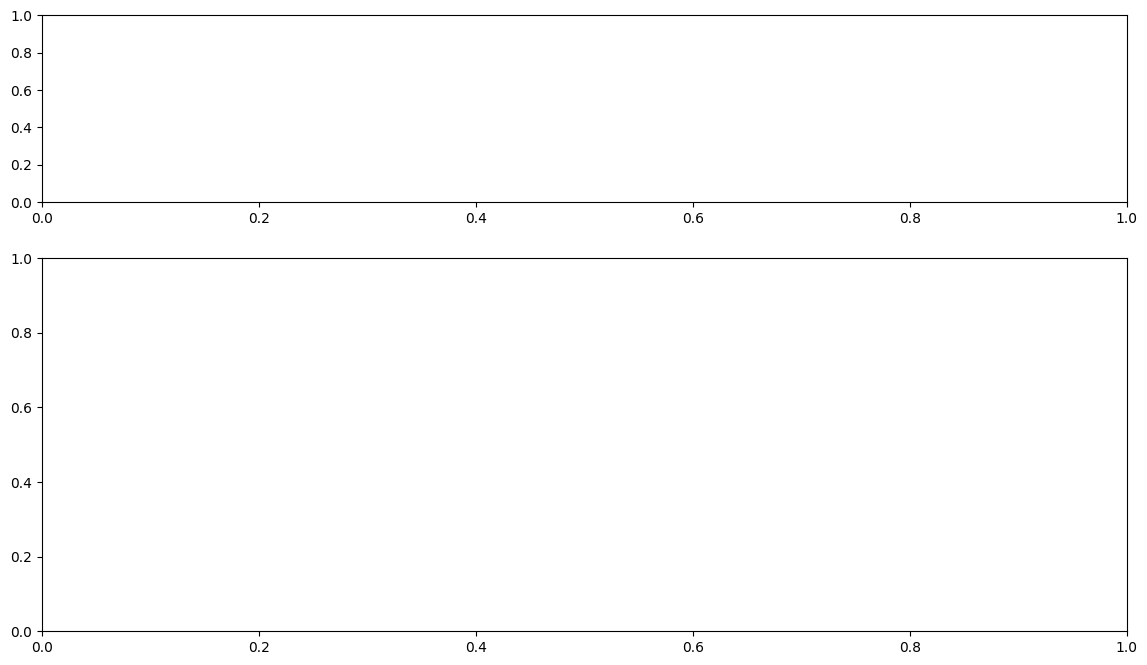

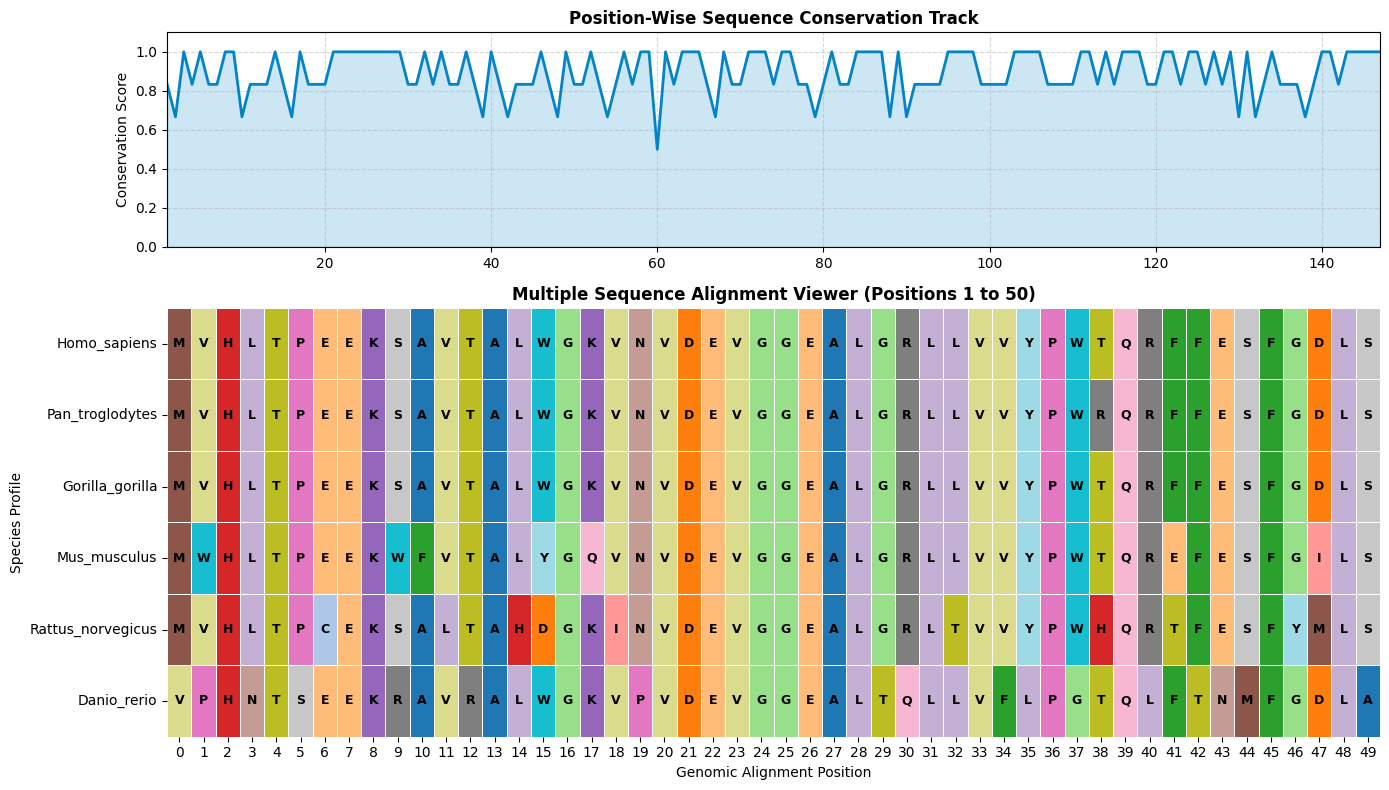

In [14]:
# Correcting the argument to gridspec_kw and using map instead of applymap
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 8), gridspec_kw={'height_ratios': [1, 2]})

# Let's run the full corrected block
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Recreate data
organisms = ["Homo_sapiens", "Pan_troglodytes", "Gorilla_gorilla", "Mus_musculus", "Rattus_norvegicus", "Danio_rerio"]
consensus = "MVHLTPEEKSAVTALWGKVNVDEVGGEALGRLLVVYPWTQRFFESFGDLSTPDAVMGNPKVKAHGKKVLGAFSDGLAHLDNLKGTFATLSELHCDKLHVDPENFRLLGNVLVCVLAHHFGKEFTPPVQAAYQKVVAGVANALAHKYH"

np.random.seed(101)
sequence_dict = {}

for i, org in enumerate(organisms):
    seq_chars = list(consensus)
    mutation_rate = 0.01 if i < 3 else (0.12 if i < 5 else 0.32)
    for idx in range(len(seq_chars)):
        if np.random.rand() < mutation_rate:
            seq_chars[idx] = np.random.choice(list("ACDEFGHIKLMNPQRSTVWY"))
    sequence_dict[org] = "".join(seq_chars)

alignment_matrix = []
for org in organisms:
    alignment_matrix.append(list(sequence_dict[org]))

df_alignment = pd.DataFrame(alignment_matrix, index=organisms)
df_alignment.index.name = "Organism"
df_alignment.to_csv("sequence_alignment_matrix.csv")

conservation_data = []
seq_len = len(consensus)

for pos in range(seq_len):
    residues = [sequence_dict[org][pos] for org in organisms]
    res_counts = pd.Series(residues).value_counts()
    most_common_res = res_counts.index[0]
    score = res_counts.max() / len(organisms)
    conservation_data.append({
        "Position": pos + 1,
        "Consensus_Residue": most_common_res,
        "Conservation_Score": score
    })

df_conservation = pd.DataFrame(conservation_data)
df_conservation.to_csv("position_conservation_scores.csv", index=False)

# Plotting
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 8), gridspec_kw={'height_ratios': [1, 2]})

ax1.plot(df_conservation["Position"], df_conservation["Conservation_Score"], color="#0284c7", linewidth=2)
ax1.fill_between(df_conservation["Position"], df_conservation["Conservation_Score"], color="#0284c7", alpha=0.2)
ax1.set_title("Position-Wise Sequence Conservation Track", fontsize=12, fontweight='bold')
ax1.set_ylabel("Conservation Score", fontsize=10)
ax1.set_xlim(1, seq_len)
ax1.set_ylim(0, 1.1)
ax1.grid(True, linestyle="--", alpha=0.5)

subset_len = 50
df_sub = df_alignment.iloc[:, :subset_len]

unique_residues = sorted(list(set("".join(sequence_dict.values()))))
res_to_num = {res: idx for idx, res in enumerate(unique_residues)}
numeric_sub = df_sub.map(lambda x: res_to_num[x]) if hasattr(df_sub, 'map') else df_sub.applymap(lambda x: res_to_num[x])

sns.heatmap(numeric_sub, cmap="tab20", cbar=False, ax=ax2, linewidths=0.5, linecolor="#ffffff")

for y in range(len(organisms)):
    for x in range(subset_len):
        ax2.text(x + 0.5, y + 0.5, df_sub.iloc[y, x], ha="center", va="center", fontsize=9, color="black", fontweight="bold")

ax2.set_title(f"Multiple Sequence Alignment Viewer (Positions 1 to {subset_len})", fontsize=12, fontweight='bold')
ax2.set_xlabel("Genomic Alignment Position", fontsize=10)
ax2.set_ylabel("Species Profile", fontsize=10)

plt.tight_layout()
plt.savefig("alignment_and_conservation_dashboard.png", dpi=300)
print("Success")

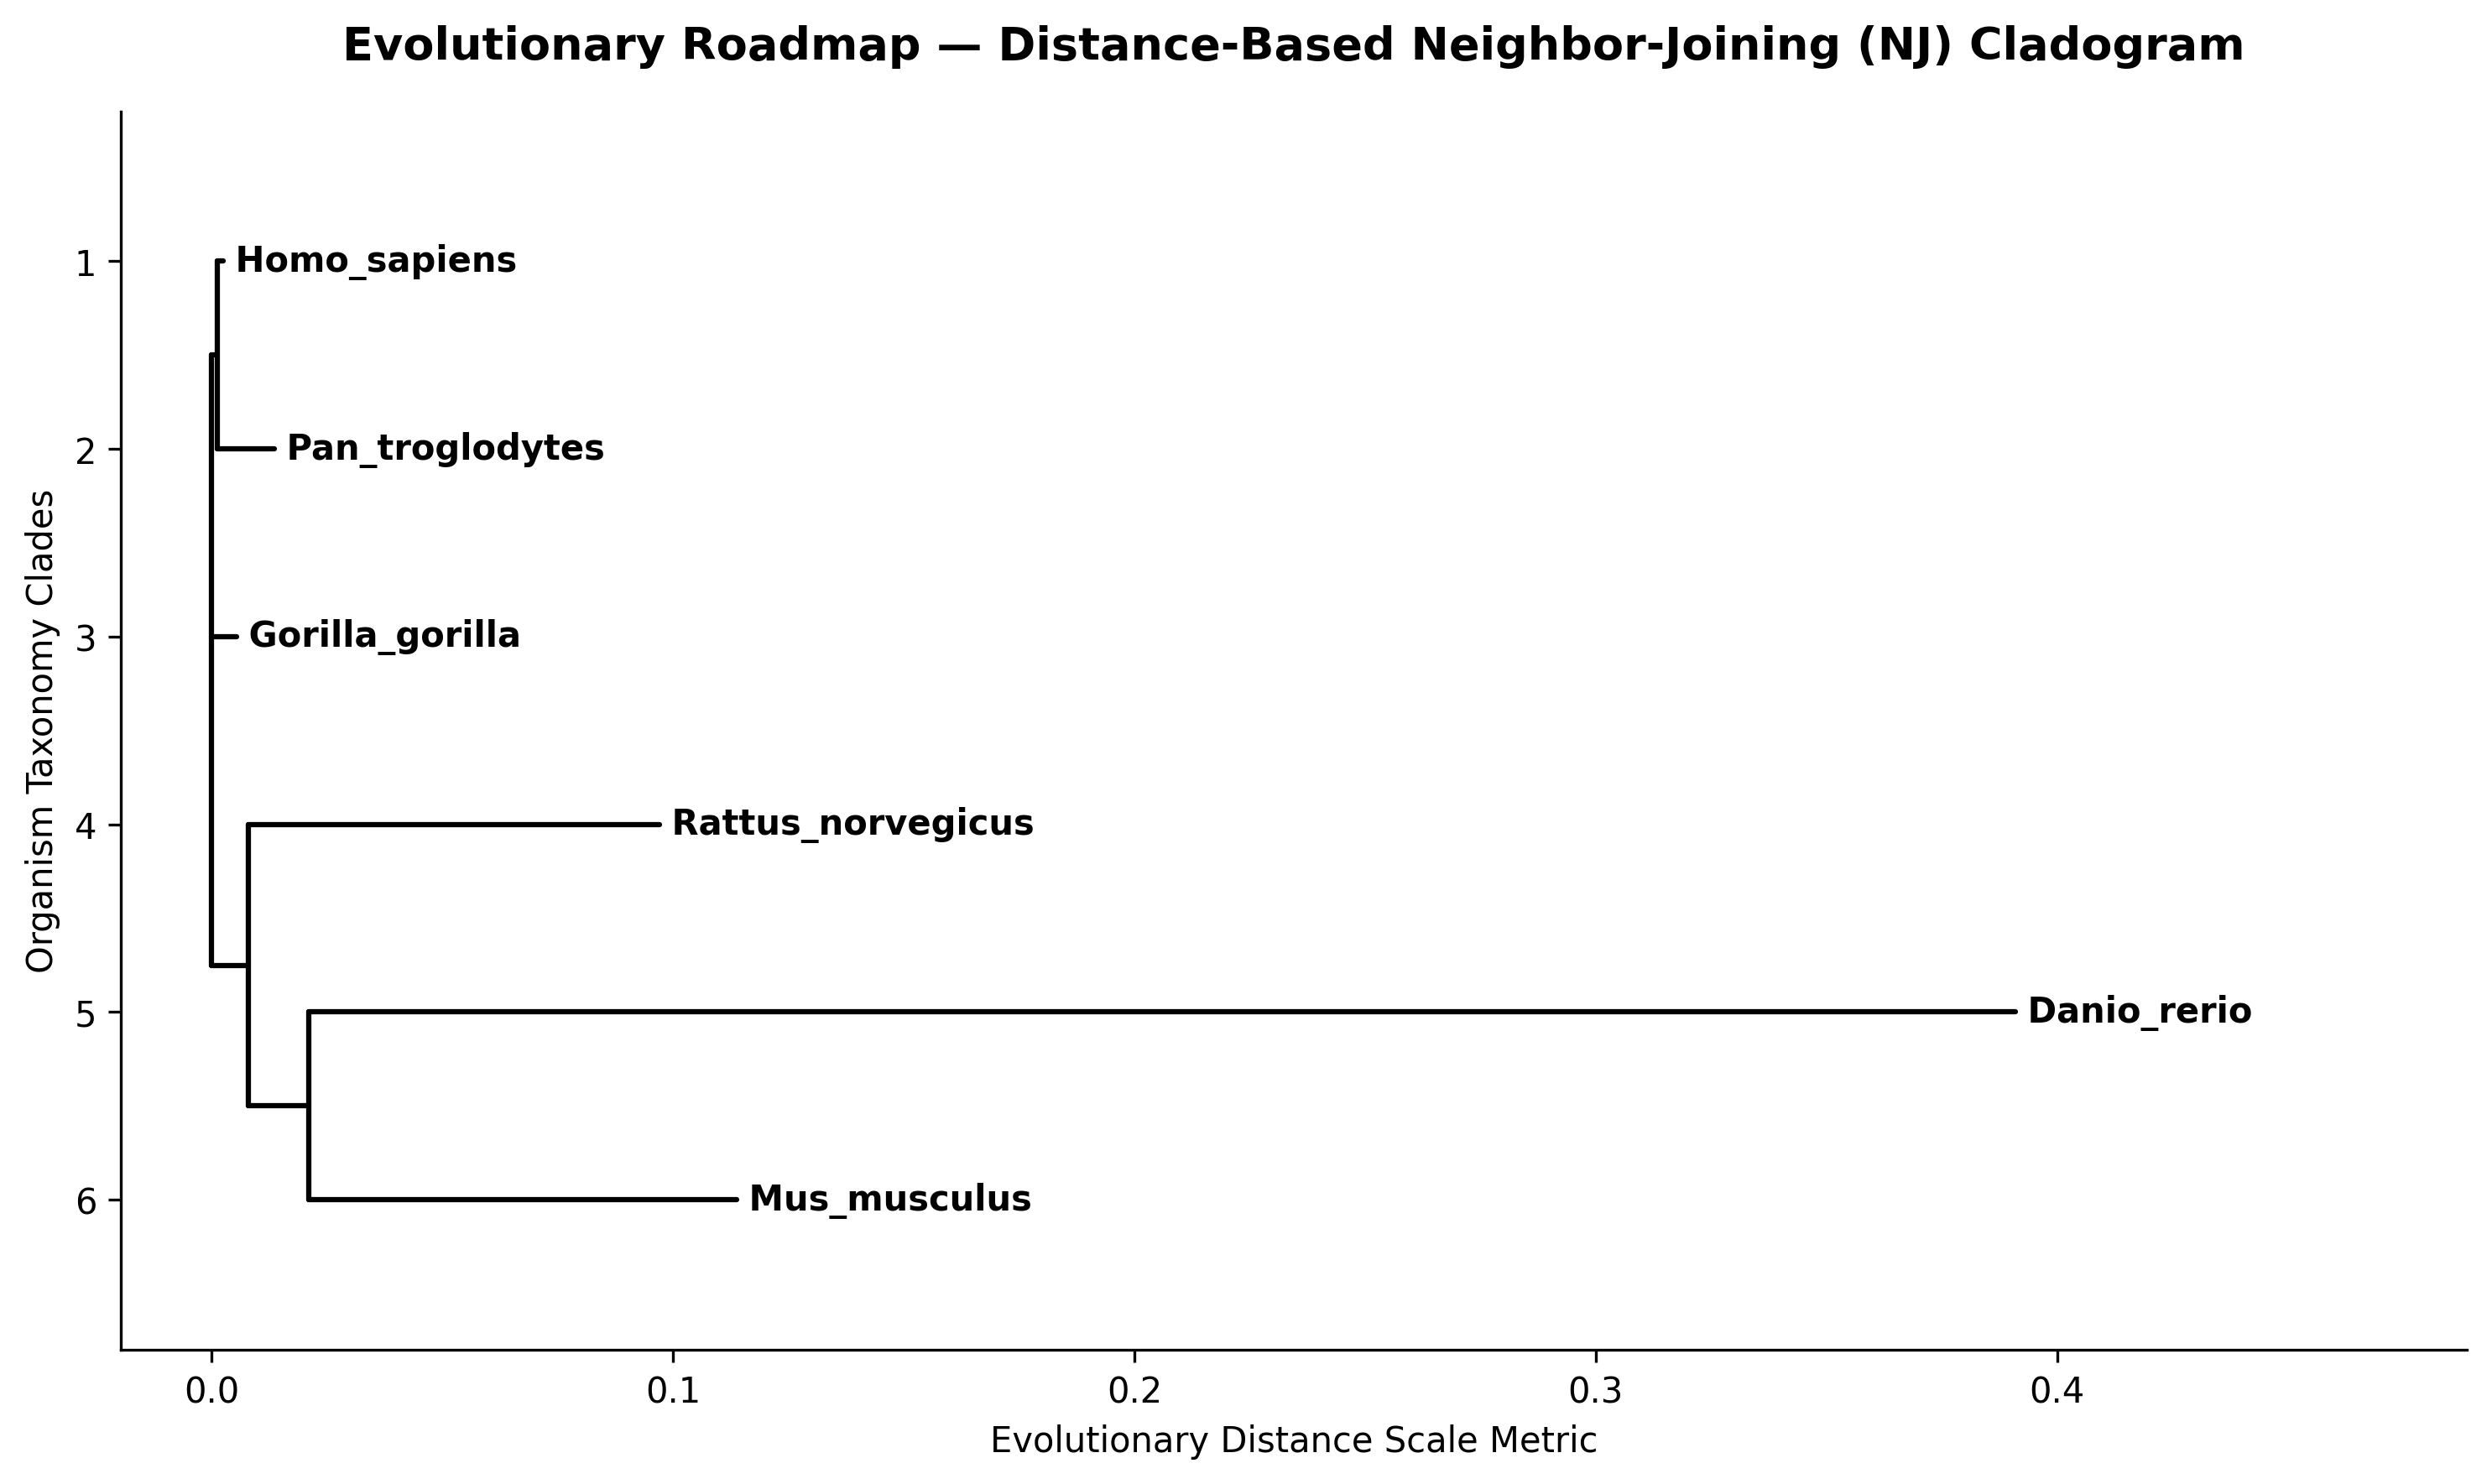

✅ Fixed! Phylogenetic tree generated successfully as 'phylogenetic_tree_structure.png'!


In [15]:
from Bio.Phylo.TreeConstruction import DistanceCalculator, DistanceTreeConstructor
from Bio.Phylo import draw
import matplotlib.pyplot as plt
import pandas as pd

# 1. Ingest sequence dataset and cast into Biopython SeqRecord containers
from Bio.Seq import Seq
from Bio.SeqRecord import SeqRecord
from Bio.Align import MultipleSeqAlignment

df_alignment = pd.read_csv("sequence_alignment_matrix.csv", index_col=0)

records = []
for organism, row in df_alignment.iterrows():
    sequence_string = "".join(row.values.astype(str))
    records.append(SeqRecord(Seq(sequence_string), id=organism))

# 2. Compile into a standard Multiple Sequence Alignment object
alignment = MultipleSeqAlignment(records)

# 3. FIXED: Calculate Distance Matrix using the supported 'identity' model
calculator = DistanceCalculator('identity')
distance_matrix = calculator.get_distance(alignment)

# 4. Construct the Phylogenetic Tree using Neighbor-Joining (NJ)
constructor = DistanceTreeConstructor()
phylo_tree = constructor.nj(distance_matrix)

# 5. Wipe out intermediate node internal labels for clean text rendering
for non_terminal in phylo_tree.get_nonterminals():
    non_terminal.name = ""

# 6. Render the tree using a Matplotlib vector canvas
fig, ax = plt.subplots(figsize=(10, 6), dpi=300)
plt.rc('font', size=10, weight='bold')
draw(phylo_tree, do_show=False, axes=ax)

ax.set_title("Evolutionary Roadmap — Distance-Based Neighbor-Joining (NJ) Cladogram", fontsize=13, fontweight='bold', pad=15)
ax.set_xlabel("Evolutionary Distance Scale Metric", fontsize=10)
ax.set_ylabel("Organism Taxonomy Clades", fontsize=10)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig("phylogenetic_tree_structure.png", dpi=300, bbox_inches='tight')
plt.show()
print("✅ Fixed! Phylogenetic tree generated successfully as 'phylogenetic_tree_structure.png'!")

/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning:

Glyph 129516 (\N{DNA DOUBLE HELIX}) missing from font(s) DejaVu Sans.

/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning:

Glyph 129516 (\N{DNA DOUBLE HELIX}) missing from font(s) DejaVu Sans.

/tmp/ipykernel_1574/3535077931.py:69: UserWarning:

Glyph 129516 (\N{DNA DOUBLE HELIX}) missing from font(s) DejaVu Sans.

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning:

Glyph 129516 (\N{DNA DOUBLE HELIX}) missing from font(s) DejaVu Sans.



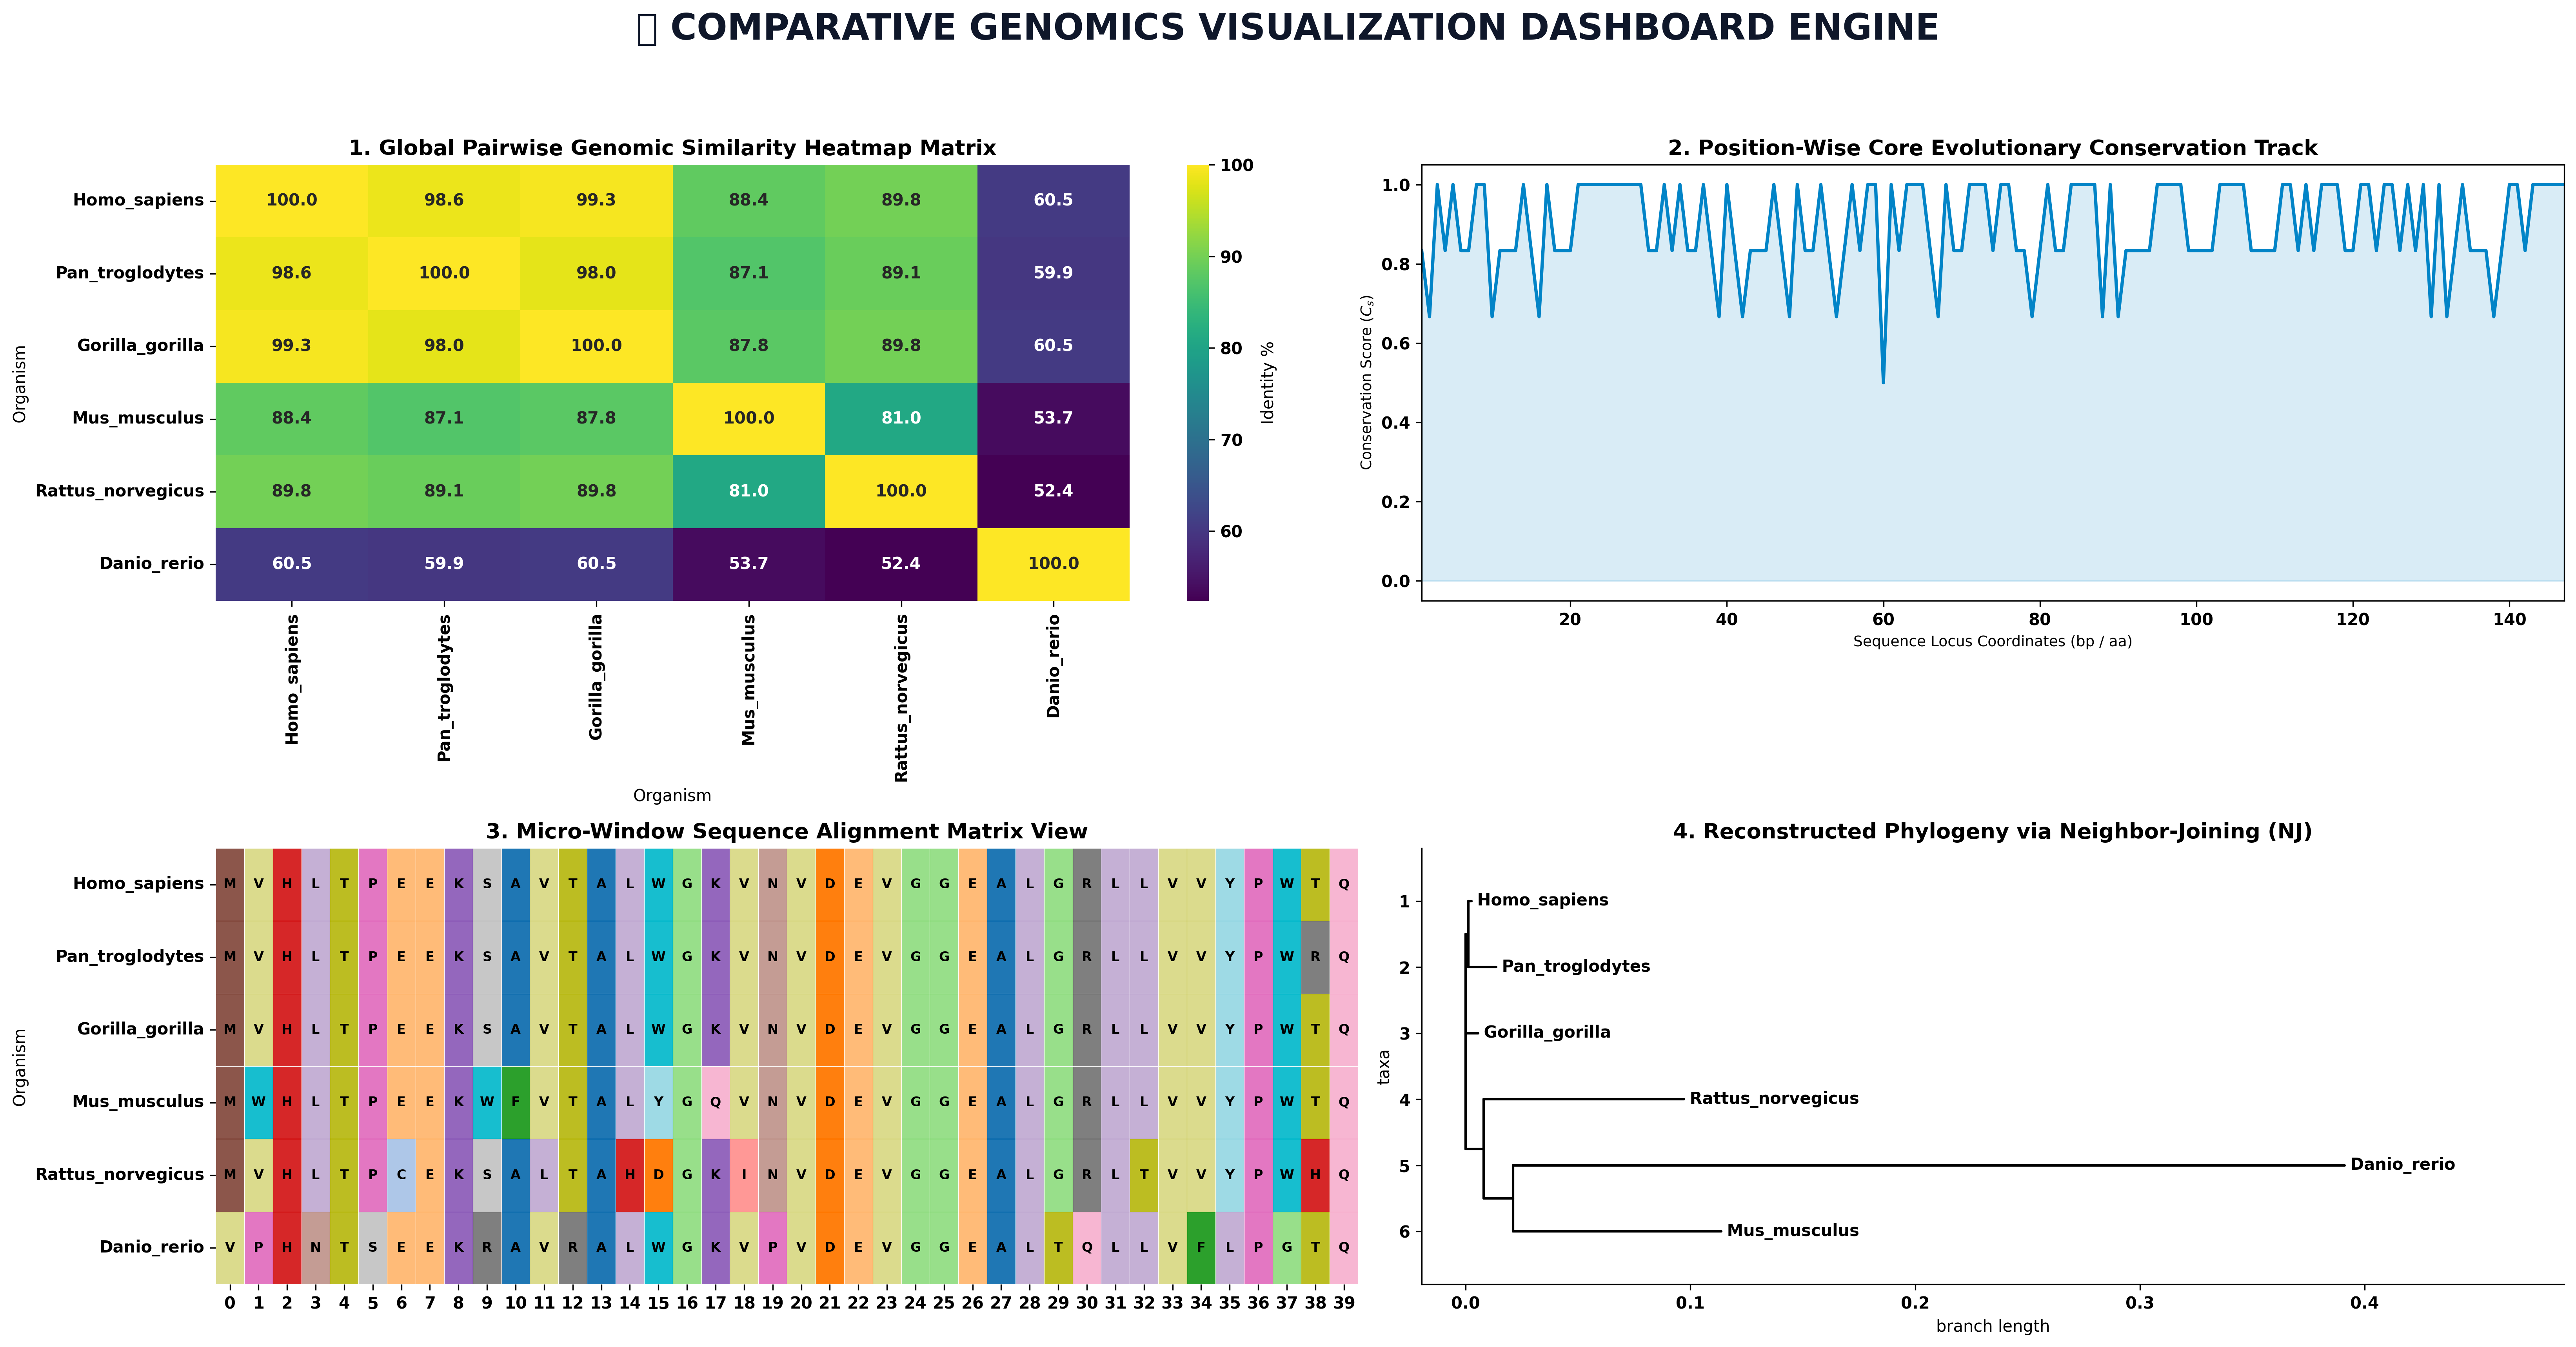

💾 Consolidated PNG dashboard layout successfully saved as 'comparative_genomics_dashboard.png'!


In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from Bio.Phylo import draw
from Bio.Seq import Seq
from Bio.SeqRecord import SeqRecord
from Bio.Align import MultipleSeqAlignment
from Bio.Phylo.TreeConstruction import DistanceCalculator, DistanceTreeConstructor

# Setup Layout Grid Canvas
fig = plt.figure(figsize=(22, 12), dpi=300)
fig.suptitle("🧬 COMPARATIVE GENOMICS VISUALIZATION DASHBOARD ENGINE", fontsize=22, fontweight='bold', color='#0f172a', y=0.98)

# --- PLOT 1: Pairwise Genome Identity Heatmap ---
ax1 = plt.subplot2grid((2, 2), (0, 0))
df_identity = pd.read_csv("sequence_alignment_matrix.csv", index_col=0)
names = df_identity.index
matrix = np.zeros((len(names), len(names)))
for i in range(len(names)):
    for j in range(len(names)):
        matrix[i, j] = (df_identity.iloc[i] == df_identity.iloc[j]).mean() * 100
df_sim = pd.DataFrame(matrix, index=names, columns=names)
sns.heatmap(df_sim, annot=True, fmt=".1f", cmap="viridis", ax=ax1, cbar_kws={'label': 'Identity %'})
ax1.set_title("1. Global Pairwise Genomic Similarity Heatmap Matrix", fontsize=13, fontweight='bold')

# --- PLOT 2: Conserved Track Sequence Line ---
ax2 = plt.subplot2grid((2, 2), (0, 1))
df_cons = pd.read_csv("position_conservation_scores.csv")
ax2.plot(df_cons["Position"], df_cons["Conservation_Score"], color="#0284c7", lw=2)
ax2.fill_between(df_cons["Position"], df_cons["Conservation_Score"], color="#0284c7", alpha=0.15)
ax2.set_title("2. Position-Wise Core Evolutionary Conservation Track", fontsize=13, fontweight='bold')
ax2.set_xlabel("Sequence Locus Coordinates (bp / aa)", fontsize=9)
ax2.set_ylabel("Conservation Score ($C_s$)", fontsize=9)
ax2.set_xlim(1, len(df_cons))

# --- PLOT 3: Multiple Sequence Alignment Heatmap Slice ---
ax3 = plt.subplot2grid((2, 2), (1, 0))
df_sub = df_identity.iloc[:, :40]
unique_res = sorted(list(set(df_identity.values.flatten())))
res_map = {r: idx for idx, r in enumerate(unique_res)}
num_sub = df_sub.map(lambda x: res_map[x]) if hasattr(df_sub, 'map') else df_sub.applymap(lambda x: res_map[x])
sns.heatmap(num_sub, cmap="tab20", cbar=False, ax=ax3, linewidths=0.2)
for y in range(len(df_identity.index)):
    for x in range(40):
        ax3.text(x + 0.5, y + 0.5, str(df_sub.iloc[y, x]), ha="center", va="center", fontsize=8, fontweight="bold")
ax3.set_title("3. Micro-Window Sequence Alignment Matrix View", fontsize=13, fontweight='bold')

# --- PLOT 4: Phylogenetic Cladogram Tree Structure ---
ax4 = plt.subplot2grid((2, 2), (1, 1))

# Re-run clean inner phylogenetic generation logic using 'identity' parameter
records = [SeqRecord(Seq("".join(row.values.astype(str))), id=org) for org, row in df_identity.iterrows()]
alignment = MultipleSeqAlignment(records)
calculator = DistanceCalculator('identity')  # FIXED HERE AS WELL
distance_matrix = calculator.get_distance(alignment)
constructor = DistanceTreeConstructor()
phylo_tree = constructor.nj(distance_matrix)
for non_terminal in phylo_tree.get_nonterminals():
    non_terminal.name = ""

draw(phylo_tree, do_show=False, axes=ax4)
ax4.set_title("4. Reconstructed Phylogeny via Neighbor-Joining (NJ)", fontsize=13, fontweight='bold')
ax4.spines['top'].set_visible(False)
ax4.spines['right'].set_visible(False)

# Render and Save Consolidated Image File
plt.tight_layout(rect=[0, 0.03, 1, 0.94])
plt.savefig("comparative_genomics_dashboard.png", dpi=300, bbox_inches='tight')
plt.show()
print("💾 Consolidated PNG dashboard layout successfully saved as 'comparative_genomics_dashboard.png'!")